# ARIMAX — Predikcia priemyselnej produkcie SR

Model s exogennymi premennymi (ARIMAX / SARIMAX). 

Struktura notebooku:
- Importy a konfiguracia
- Nacitanie a cistenie dat
- ADF test stacionarity (`functions.adf_test`)
- ACF / PACF — identifikacia lagov
- BIC forward selection exogennych premennych
- Train / test split (`functions.train_test_split_exog`)
- Odhad ARIMAX modelu
- Diagnostika reziduaov
- Predikcia a hodnotenie (`functions.evaluate_forecast`, `functions.plot_forecast`)

In [1]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import functions
importlib.reload(functions)
from functions import forward_selection
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Importy uspesne.")


Importy uspesne.


In [ ]:
# konfiguracia a stiahnutie dat
DATA_PATH  = r"C:\Users\adamv\Desktop\ADAM\VS\Diplomovka\excel\data_mod.csv"
SHEET_NAME = "all"
df_raw = pd.read_csv(DATA_PATH)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

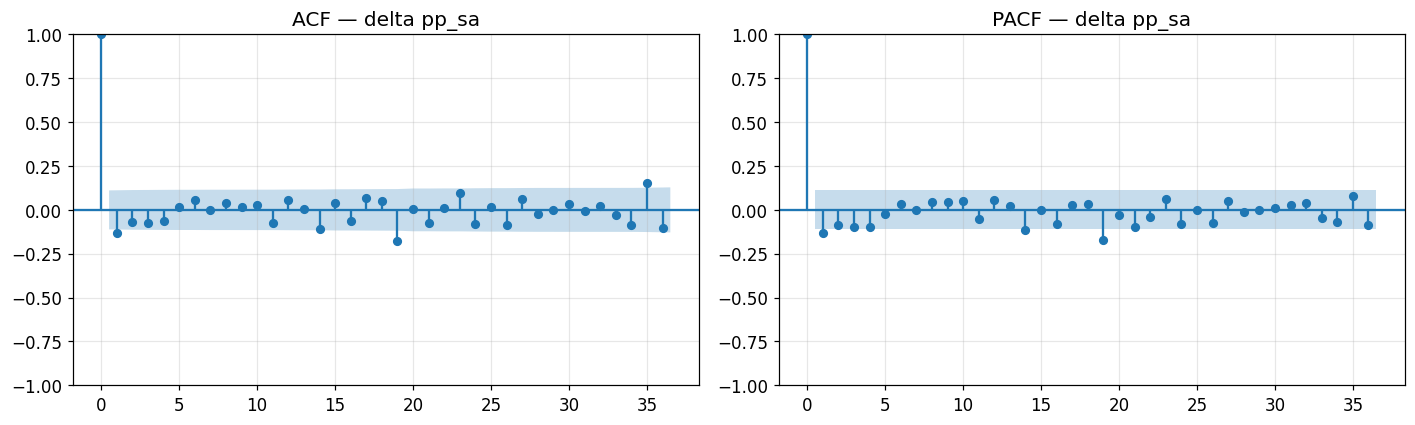

In [13]:
# identifikacia poctu lagov
# ACF => MA (q)
# PACF => AR (p)

y_diff = df["pp_sa"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( y_diff, lags=36, ax=axes[0], title="ACF — delta pp_sa")
plot_pacf(y_diff, lags=36, ax=axes[1], title="PACF — delta pp_sa")
plt.tight_layout()
#plt.savefig("figures/02_acf_pacf.png", dpi=150)
plt.show()


In [27]:
# vyber premennych do modelu na zaklade znizovania BIC
#df.drop(columns=["pp"], inplace = True)
selected_cols = forward_selection(df,"pp_sa")

BIC forward selection:
--------------------------------------------------
  + 'export_celkovy_sa'  BIC = 1547.98
  + 'crisis_dummy'  BIC = 1494.11
  + 'trzby_priemysel_sa'  BIC = 1486.17
  + 'cpi'  BIC = 1483.22
  + 'kurz_usd_eur'  BIC = 1482.42
  Zastavenie — pridanie ziadnej premennej nezlepsuje BIC.
--------------------------------------------------
Vybrane premenne: ['export_celkovy_sa', 'crisis_dummy', 'trzby_priemysel_sa', 'cpi', 'kurz_usd_eur']
Finalny BIC    : 1482.42


In [15]:
# korelacna matica vybranych premennych
df[selected_cols + ["pp_sa"]].corr()

,export_celkovy_sa,crisis_dummy,trzby_priemysel_sa,cpi,kurz_usd_eur,pp_sa
export_celkovy_sa,1.000000,0.079359,0.737235,0.053104,-0.006487,0.595564
crisis_dummy,0.079359,1.000000,0.064610,0.084613,0.031457,-0.181521
trzby_priemysel_sa,0.737235,0.064610,1.000000,0.087467,-0.021052,0.599478
cpi,0.053104,0.084613,0.087467,1.000000,-0.020443,-0.074263
kurz_usd_eur,-0.006487,0.031457,-0.021052,-0.020443,1.000000,0.053168
pp_sa,0.595564,-0.181521,0.599478,-0.074263,0.053168,1.000000


In [28]:
selected_cols.remove("kurz_usd_eur")


In [30]:
# urcenie rozsah testovacej mnoziny a rozdelenie dat na train/test
TEST_SIZE = 24

train_y, test_y, train_exog, test_exog = functions.train_test_split_exog(
    df   = df,
    y_col = "pp_sa",
    exog_cols = selected_cols if selected_cols else None,
    train_ratio = 1 - TEST_SIZE / len(df),
)

print(f"Trenovacia mnozina: {train_y.index.min().date()} az {train_y.index.max().date()} ({len(train_y)} obs.)")
print(f"Testovacia mnozina: {test_y.index.min().date()} az {test_y.index.max().date()} ({len(test_y)} obs.)")


Trenovacia mnozina: 2000-02-01 az 2023-12-01 (287 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [31]:
# odhad modelu
# enforce_stationarity/invertibility=False — model neobmedzi priestor parametrov, co umoznuje stabilnejsiu konvergenciu.

BASE_ORDER = (1,0,1)
SEAS_ORDER = (0, 0, 0,12)

model_fit = SARIMAX(
    train_y,
    exog              = train_exog,
    order             = BASE_ORDER,
    seasonal_order    = SEAS_ORDER,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False, cov_type="robust")

print(model_fit.summary()) 


                               SARIMAX Results                                
Dep. Variable:                  pp_sa   No. Observations:                  287
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -670.012
Date:                Fri, 07 Aug 2026   AIC                           1354.024
Time:                        09:12:42   BIC                           1379.591
Sample:                    02-01-2000   HQIC                          1364.273
                         - 12-01-2023                                         
Covariance Type:               robust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
export_celkovy_sa      0.0064      0.001      5.936      0.000       0.004       0.009
crisis_dummy         -14.9126      3.949     -3.777      0.000     -22.652      -7.174
trzby_priemysel_sa  

datum
2005-01-01    -9.206787
2007-12-01    -8.763949
2008-08-01    -6.351090
2009-01-01    -4.606466
2008-01-01    -4.563551
                ...    
2009-07-01     5.313447
2006-11-01     6.626845
2007-03-01     6.687220
2004-12-01    11.035320
2007-11-01    12.955264
Length: 72, dtype: float64


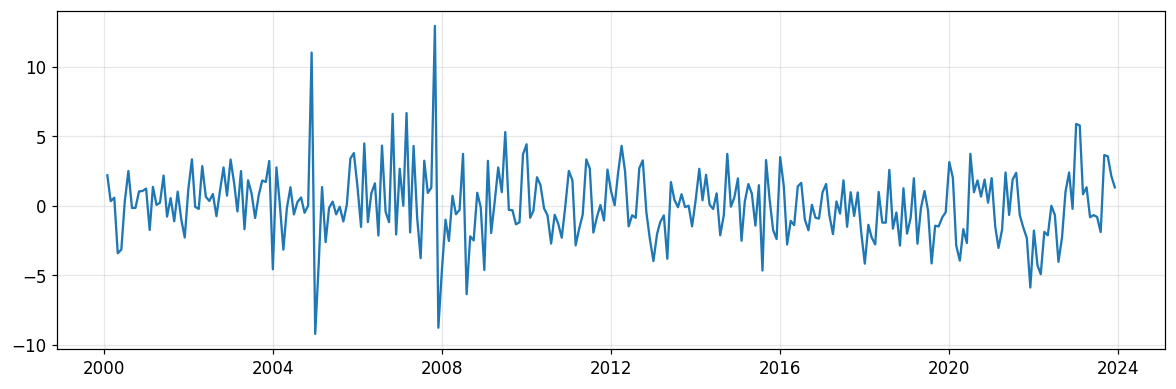

In [32]:
# vizualizacia rezidualov modelu
plt.plot(model_fit.resid)
print(model_fit.resid.loc["2004-01":"2009-12"].sort_values())

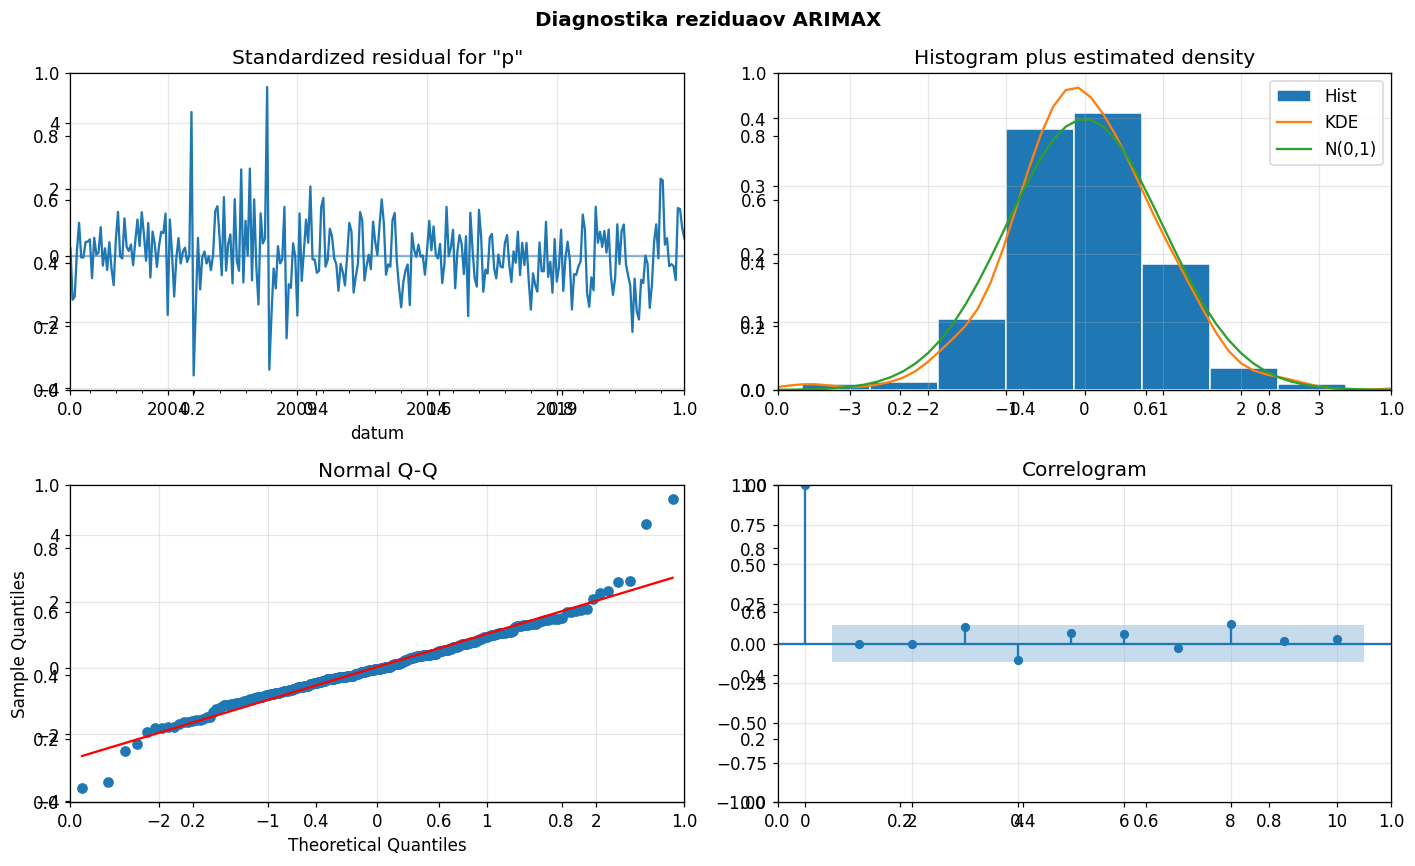


Ljung-Box test (H0: ziadna autokorelacia reziduaov):
      lb_stat  lb_pvalue
12  23.160581   0.026393
24  57.424725   0.000146


In [33]:
# diagnostika rezidualov

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
model_fit.plot_diagnostics(fig=fig)
plt.suptitle("Diagnostika reziduaov ARIMAX", fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("figures/03_diagnostika_rezidualy.png", dpi=150)
plt.show()


residuals = model_fit.resid.dropna()
lb = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("\nLjung-Box test (H0: ziadna autokorelacia reziduaov):")
print(lb.to_string())


In [34]:
# evaluacia modelu cez RMSE, MAPE a ME
last_train_value = train_y.iloc[-1]
forecast = functions.evaluate_forecast(model_fit, test_y, test_exog, last_train_value, original=True)


RMSE: 2.0866
MAPE: 732.58%
ME:   -0.5008


In [35]:
# zobrazenie najvacsich chyb
errors = test_y - forecast
print(errors.sort_values())
print(errors.abs().sort_values(ascending=False).head(10))

datum
2025-01-01   -6.173885
2024-04-01   -2.876962
2025-10-01   -2.104593
2025-12-01   -2.020607
2025-09-01   -1.607341
2025-05-01   -1.163329
2025-02-01   -1.063747
2024-09-01   -0.827307
2024-11-01   -0.549439
2024-01-01   -0.526504
2024-10-01   -0.504302
2024-07-01   -0.482000
2025-11-01   -0.322365
2025-06-01    0.054499
2024-03-01    0.203317
2025-07-01    0.321953
2025-04-01    0.615488
2024-06-01    0.662003
2024-08-01    0.839797
2025-03-01    1.232069
2024-02-01    1.974605
2024-05-01    2.051275
2025-08-01    3.880114
2024-12-01    3.950956
dtype: float64
datum
2025-01-01    6.173885
2024-12-01    3.950956
2025-08-01    3.880114
2024-04-01    2.876962
2025-10-01    2.104593
2024-05-01    2.051275
2025-12-01    2.020607
2024-02-01    1.974605
2025-09-01    1.607341
2025-03-01    1.232069
dtype: float64


In [36]:
# staticka evaluacia modelu s posunom
train_size  = len(train_y) 
for h in [6, 12, 18, 24]:
    test_h = test_y.iloc[:h]
    test_exog_h = test_exog.iloc[:h]
    
    print(f"--- Horizont {h} ---")
    print("Level (original=True):")
    functions.evaluate_forecast(model_fit, test_h, test_exog_h, last_train_value, original=True)
    print("Delta (original=False):")
    functions.evaluate_forecast(model_fit, test_h, test_exog_h, last_train_value, original=False)

--- Horizont 6 ---
Level (original=True):
RMSE: 1.2582
MAPE: 2534.38%
ME:   0.6102
Delta (original=False):
RMSE: 1.6902
MAPE: 203.00%
ME:   0.2480
--- Horizont 12 ---
Level (original=True):
RMSE: 1.5955
MAPE: 1294.04%
ME:   0.9937
Delta (original=False):
RMSE: 1.7061
MAPE: 173.42%
ME:   0.3263
--- Horizont 18 ---
Level (original=True):
RMSE: 1.9273
MAPE: 938.94%
ME:   -0.1357
Delta (original=False):
RMSE: 2.0741
MAPE: 653.99%
ME:   -0.1435
--- Horizont 24 ---
Level (original=True):
RMSE: 2.0866
MAPE: 732.58%
ME:   -0.5008
Delta (original=False):
RMSE: 2.0796
MAPE: 630.12%
ME:   -0.1848


In [37]:
# rolling evaluacia modelu s posunom

results = []
for origin_shift in range(0, 24, 3):   # napr. každé 3 mesiace posun
    train_size_i = train_size - origin_shift
    train_i = df["pp_sa"].iloc[:train_size_i]
    test_i  = df["pp_sa"].iloc[train_size_i:train_size_i+24]
    test_exog_i = df[test_exog_h.columns].iloc[train_size_i:train_size_i+24]
    
    model_i = SARIMAX(train_i, exog=df[test_exog_h.columns].iloc[:train_size_i], order=(1,0,1))
    res_i = model_i.fit(disp=False)
    
    forecast_i = res_i.forecast(steps=24, exog=test_exog_i)
    rmse_i = np.sqrt(np.mean((test_i.values - forecast_i.values)**2))
    results.append(rmse_i)
    print(f"Origin posun {origin_shift}: RMSE={rmse_i:.3f}")

print(f"\nPriemerne RMSE cez vsetky origin body: {np.mean(results):.3f}")

Origin posun 0: RMSE=2.086
Origin posun 3: RMSE=2.147
Origin posun 6: RMSE=2.096
Origin posun 9: RMSE=2.120
Origin posun 12: RMSE=2.448
Origin posun 15: RMSE=2.546
Origin posun 18: RMSE=2.556
Origin posun 21: RMSE=2.338

Priemerne RMSE cez vsetky origin body: 2.292


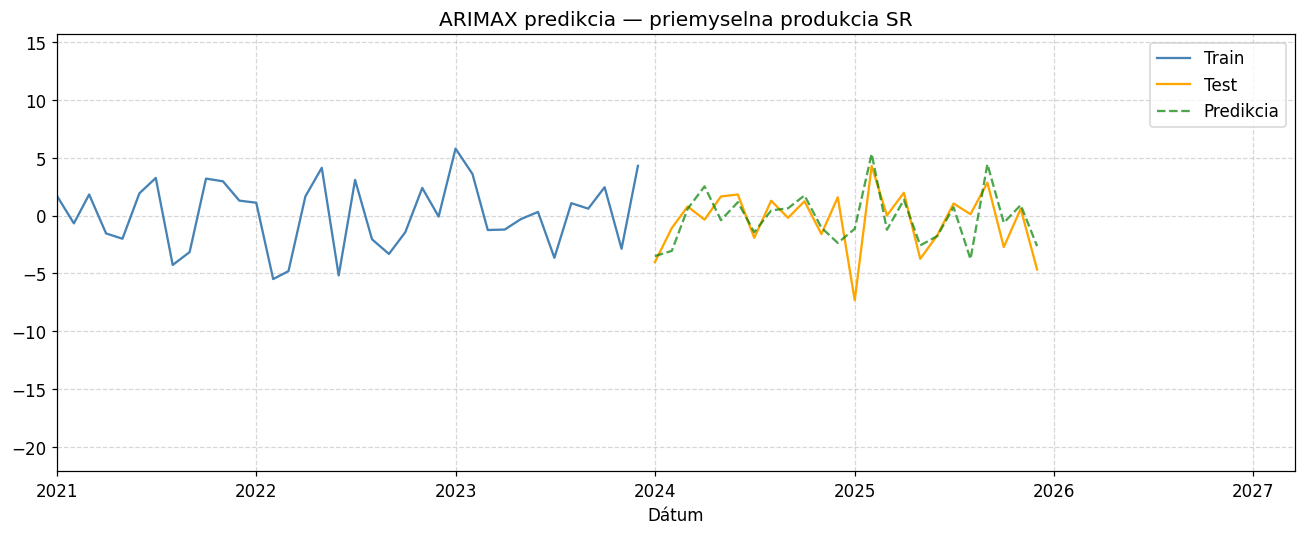

In [38]:
# vizualizacie predikcie

functions.plot_forecast(
    train     = train_y,
    test      = test_y,
    forecast  = forecast,
    title     = f"ARIMAX predikcia — priemyselna produkcia SR",
    zoom_from = test_y.index[0] - pd.DateOffset(months=36),
)

#plt.savefig("figures/04_predikcia_arimax.png", dpi=150, bbox_inches="tight")

